<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/03_clustering/03_DBSCAN_Clustering_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3: Unsupervised Learning (DBSCAN Clustering)

In this notebook, we apply DBSCAN (Density-Based Spatial Clustering of Applications with Noise) to our master customer dataset.

Unlike K-Means, which forces every household into a pre-defined spherical cluster, DBSCAN groups households based on the density of their behaviors. This allows us to discover organically shaped customer segments and explicitly isolate anomalous shoppers as "Noise".

### Step 1: Loading & Scaling
We will load the dataset containing our K-Means labels so we can compare the two algorithms later. We must drop the categorical identifiers and scale the numerical features so DBSCAN's radius (`eps`) is calculated fairly across all variables.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Set chart aesthetic
sns.set_theme(style="whitegrid")

# 1. Load the dataset (Make sure 'customers_with_kmeans_labels.csv' is uploaded to this new session!)
df = pd.read_csv('customers_with_kmeans_labels.csv')

# 2. Isolate the features we want to cluster (dropping IDs and previous K-Means labels)
columns_to_drop = ['household_id', 'Cluster', 'Persona']
features = df.drop(columns=columns_to_drop, errors='ignore')

# We only want to scale the numerical features
numerical_features = features.select_dtypes(include=['int64', 'float64'])

# 3. Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numerical_features)

print(f"Successfully loaded and scaled {scaled_features.shape[0]} customer profiles.")
print(f"Features used for DBSCAN: {list(numerical_features.columns)}")

Successfully loaded and scaled 801 customer profiles.
Features used for DBSCAN: ['total_spend', 'total_quantity', 'total_transactions', 'avg_item_price', 'avg_basket_value', 'age_encoded', 'income_encoded', 'kids_encoded']


### Step 2: Finding the Optimal Epsilon (eps)

To train DBSCAN, we must define the `eps` parameter (the maximum radius of a neighborhood). If we set it too low, everyone becomes an outlier. If we set it too high, everyone merges into one giant, useless cluster.

We will find the optimal `eps` mathematically by plotting a **K-Distance Graph**. We calculate the distance from every data point to its nearest neighbors, sort those distances, and look for the "elbow" or sharp upward bend in the plot. That bend indicates the exact distance where distinct dense clusters end and scattered outliers begin.

Number of features: 8. Setting min_samples to 16.


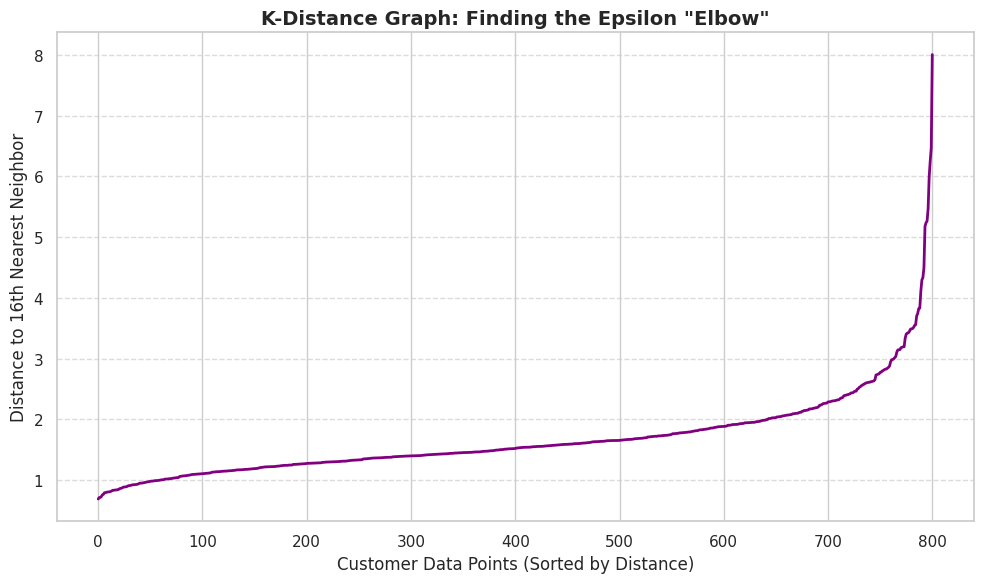

In [3]:
# 1. Define min_samples (Rule of thumb: 2 * number of features)
num_features = scaled_features.shape[1]
min_samples_val = num_features * 2
print(f"Number of features: {num_features}. Setting min_samples to {min_samples_val}.")

# 2. Calculate the distance to the nearest neighbors for every data point
neighbors = NearestNeighbors(n_neighbors=min_samples_val)
neighbors_fit = neighbors.fit(scaled_features)
distances, indices = neighbors_fit.kneighbors(scaled_features)

# 3. Sort the distances from smallest to largest
# We take the distances to the furthest neighbor in our min_samples radius
sorted_distances = np.sort(distances[:, min_samples_val - 1], axis=0)

# 4. Plot the K-Distance Graph
plt.figure(figsize=(10, 6))
plt.plot(sorted_distances, color='purple', linewidth=2)
plt.title('K-Distance Graph: Finding the Epsilon "Elbow"', fontsize=14, fontweight='bold')
plt.xlabel('Customer Data Points (Sorted by Distance)', fontsize=12)
plt.ylabel(f'Distance to {min_samples_val}th Nearest Neighbor', fontsize=12)

# Adding a grid specifically on the y-axis to help us spot the exact decimal value
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Explanation
If you follow the purple line from left to right, it maintains a very gentle, steady slope. But right around the 2.5 mark on the Y-axis, it hits a sharp inflection point and shoots almost straight up into the air.

That sharp bend—the "elbow"—is our optimal Epsilon.

**Here is what that means:**

* Most customers naturally group together with a distance of 2.5 or less between their purchasing behaviors.

* Those few customers on the far right (where the line spikes up to 4, 6, and 8) are the extreme outliers. They are so far away from the normal groups that forcing them into a cluster would ruin our model. DBSCAN is going to officially brand them as Noise (-1).

Let's plug eps=2.5 into the algorithm and see how DBSCAN handles the messy reality of this dataset

### Step 3: Training DBSCAN and Identifying Noise

Based on the K-Distance Graph, the optimal Epsilon (`eps`) radius is approximately 2.5. We will combine this with our `min_samples` of 16 to train the DBSCAN algorithm.

Unlike K-Means, which assigns cluster numbers from 0 upwards, DBSCAN introduces a special label: **-1**. Any customer assigned to cluster `-1` is officially classified as "Noise" (an outlier) because their purchasing behavior is too erratic to fit into any dense neighborhood.

In [4]:
# 1. Initialize DBSCAN with our discovered parameters
dbscan = DBSCAN(eps=2.5, min_samples=16)

# 2. Fit the model and predict the cluster labels
dbscan_labels = dbscan.fit_predict(scaled_features)

# 3. Attach the new DBSCAN labels to our main dataframe
df['DBSCAN_Cluster'] = dbscan_labels

# 4. Summarize the results
print("DBSCAN Cluster Assignments:")
print("-" * 30)

# Count how many customers fell into each cluster (and how many are noise)
cluster_counts = df['DBSCAN_Cluster'].value_counts().sort_index()

for cluster_id, count in cluster_counts.items():
    if cluster_id == -1:
        print(f"Cluster {cluster_id} (Noise/Outliers): {count} households")
    else:
        print(f"Cluster  {cluster_id} (Core Segment)  : {count} households")

DBSCAN Cluster Assignments:
------------------------------
Cluster -1 (Noise/Outliers): 22 households
Cluster  0 (Core Segment)  : 779 households


1. The 22 Outliers (Cluster -1):
DBSCAN successfully hunted down the 22 households whose purchasing behaviors are so extreme or chaotic that they don't belong in any normal demographic. This is incredibly valuable for Anomaly Detection.

2. The 779 Core Segment (Cluster 0):
Notice how DBSCAN put almost everyone else into a single, massive cluster? This tells us a deep truth about our grocery dataset: customer shopping habits do not exist on isolated islands. Instead, grocery shopping is one massive, continuous spectrum.

* K-Means took that continuous spectrum and took a machete to it, artificially chopping it into 3 neat marketing segments (Budget, Bulk, Loyal).

* DBSCAN looked at the exact same data and said, "Mathematically, these people are all packed tightly enough together to be one giant neighborhood, except for those 22 weirdos over there."

### Step 4: Visualizing the Algorithmic Differences

To understand why DBSCAN grouped 779 households into one core segment and isolated 22 as noise, we will plot the DBSCAN results side-by-side with our previous K-Means results.

We will use the same axes (**Total Store Visits** vs. **Total Lifetime Spend**):
*   **K-Means (Left):** Artificially slices the data into 3 distinct marketing personas.
*   **DBSCAN (Right):** Treats the main data cloud as a single continuous neighborhood and explicitly flags the extreme outliers (Noise).

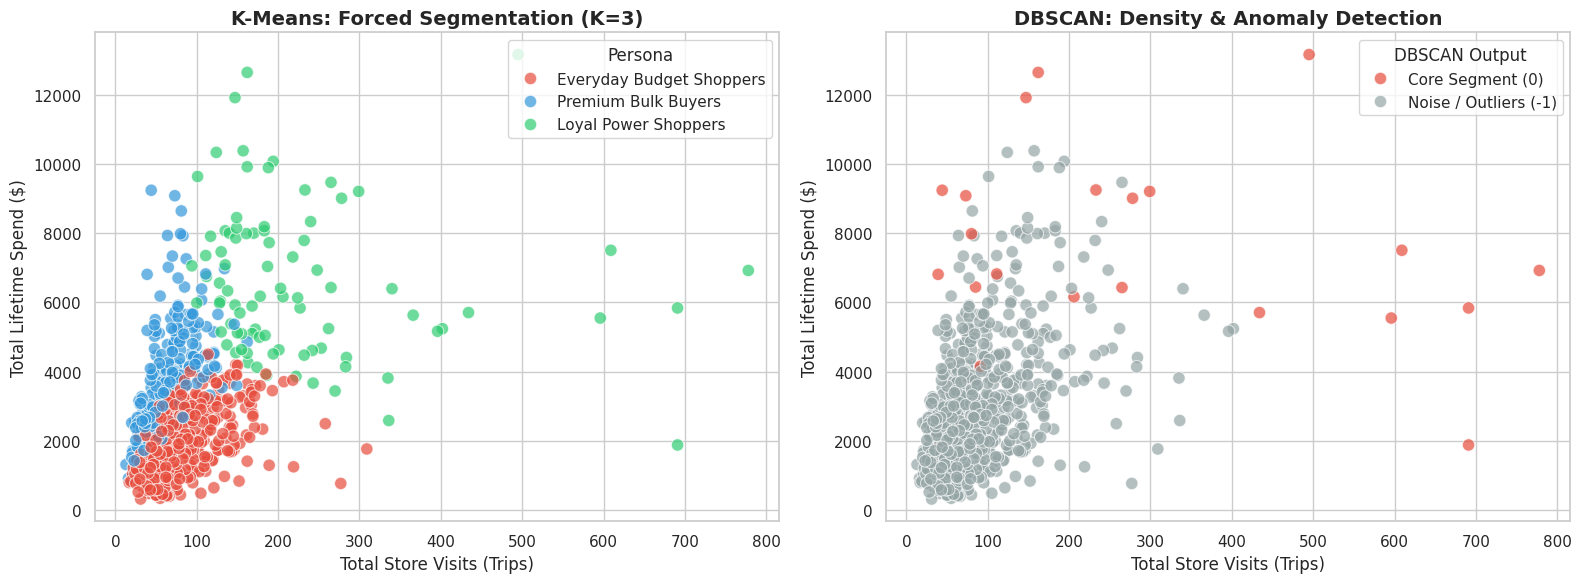

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- PLOT 1: K-MEANS (From Phase 2) ---
sns.scatterplot(
    ax=axes[0],
    data=df,
    x='total_transactions',
    y='total_spend',
    hue='Persona',
    palette=['#e74c3c', '#3498db', '#2ecc71'],
    s=80,
    alpha=0.7
)
axes[0].set_title('K-Means: Forced Segmentation (K=3)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Store Visits (Trips)', fontsize=12)
axes[0].set_ylabel('Total Lifetime Spend ($)', fontsize=12)
axes[0].legend(title='Persona')

# --- PLOT 2: DBSCAN (From Phase 3) ---
# Create a custom color palette: Red for Noise (-1), Grey for Core Segment (0)
dbscan_palette = {-1: '#e74c3c', 0: '#95a5a6'}

sns.scatterplot(
    ax=axes[1],
    data=df,
    x='total_transactions',
    y='total_spend',
    hue='DBSCAN_Cluster',
    palette=dbscan_palette,
    s=80,
    alpha=0.7
)
axes[1].set_title('DBSCAN: Density & Anomaly Detection', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Store Visits (Trips)', fontsize=12)
axes[1].set_ylabel('Total Lifetime Spend ($)', fontsize=12)

# Customizing the legend to make it clear what -1 and 0 mean
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=['Core Segment (0)', 'Noise / Outliers (-1)'], title='DBSCAN Output')

plt.tight_layout()
plt.show()

Looking closely at the outer edges of the K-Means plot on the left, you can see how it forced those extreme, high-spending outliers into the green "Loyal Power Shoppers" category, stretching the boundaries of what a "normal" power shopper looks like. But on the right, DBSCAN accurately recognized that those sparse points at the top and far right don't belong in the main cluster at all, they are true anomalies.

### Step 5: Exporting the DBSCAN Results

We successfully used DBSCAN for anomaly detection, identifying 22 extreme outlier households. We will now save this updated dataset. It contains our original features, the K-Means personas, and the new DBSCAN anomaly labels.



In [6]:
# Save the updated dataframe to the Colab environment
df.to_csv('customers_with_dbscan_labels.csv', index=False)

print("DBSCAN results successfully saved!")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns.")

DBSCAN results successfully saved!
Dataset shape: 801 rows, 19 columns.
